# Calculating temporal statistics (advanced)

In this example, we move beyond basic data extraction and compute temporal statistics (such as the linear trend in ice speed and its statistical significance (p-value)) on a pixel-by-pixel basis. Analyzing these time-series allows us to identify where glaciers are actively accelerating or slowing down, which is critical for understanding broader ice sheet dynamics.

While we will focus on a moderately sized subset in West Greenland to ensure this notebook runs quickly on any machine, the workflow is explicitly designed to scale up to the entire ice sheet.

### Managing the workload with Dask
Time-series analysis on large multidimensional datasets (like our Zarr stores) is computationally expensive and memory-intensive. If we tried to load the entire dataset into memory at once, the system would likely crash. To prevent this, we use **Dask** for out-of-core, parallel computation.

First, we will load our core dependencies and initialize a LocalCluster. Here is what is happening under the hood:
* `xarray` & `rioxarray`: For lazily loading and managing the multidimensional, geospatial data cube.
* `scipy.stats` & `numpy`: For performing the rigorous mathematical modeling on the data arrays.
* `pyproj`: To handle spatial coordinate transformations so we can easily subset our data.
* `LocalCluster`: This automatically inspects the machine running the notebook, creates a pool of "workers" based on the available CPU cores, and actively manages memory limits so we don't overflow the RAM.

> _Tip: If you run the cell below, an HTML representation of the `client` will appear. Clicking the **Dashboard link** opens a new tab where you can watch Dask distribute the tasks across your CPU cores in real-time_

In [1]:
import warnings
import numpy as np
import xarray as xr
import rioxarray
import scipy.stats
import matplotlib.pyplot as plt
from pyproj import Transformer
from dask.distributed import Client, LocalCluster, performance_report
import dask

# Spin up a local Dask cluster
cluster = LocalCluster()
client = Client(cluster)

# Display the dashboard link so users can watch the processing graph
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 8,Total memory: 63.79 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:52131,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:52159,Total threads: 2
Dashboard: http://127.0.0.1:52160/status,Memory: 15.95 GiB
Nanny: tcp://127.0.0.1:52134,


## Define function to calculate temporal statistics
Next, we need to define the mathematical operations we want to perform on our velocity data. We will extract four key metrics for every single pixel:
* **Time-average mean speed**
* **Measurement count:** The number of valid (non-NaN) observations over time, which helps us gauge the reliability of the trend.
* **Linear trend** The rate of change in speed over time (acceleration or deceleration).
* **Significance (p-value):** The statistical confidence that the observed trend is real and not just random noise.

### Why write a custom, pure-NumPy function?
If you look closely at the code below, you will notice we calculate the linear regression (slope and p-value) manually using sums of squares (`numerator`, `denominator`, `ss_res`), rather than using a built-in tool like `scipy.stats.linregress`.

There are two major reasons for this design choice:
1. **Multi-dimensional Vectorization:** Standard functions like `scipy.stats.linregress` are designed to work on 1D arrays (a single pixel at a time). If we used a for loop to apply a 1D function across this many spatial pixels, it would take a little too long for this example. By writing the math out using NumPy primitives and specifying `axis=-1` (the time dimension), we evaluate the trend for an entire 3D block of data (y, x, time) simultaneously at C-level speed.
2. **Missing Data Handling:** Ice velocity fields derived from satellite imagery always suffers from some data gaps. By using `np.nanmean` and `np.nansum`, our manual regression ignores these missing data slices without throwing errors. Of course, this means we are actually calculating a trend through varying numbers of data points and varying time periods in each pixel. To make this analysis robust, we would need to identify which pixels had sufficient data that was sufficiently spread over the time period of interest to calculate a representative trend. However, since this is just an example to illustrate the process, we will skip those important details here.

In [2]:
def _calc_stats_numpy(y, t):
    """
    Pure NumPy function to calculate stats along the last axis (-1).
    y shape: (..., time), t shape: (time,)
    """
    y = y.astype(float)
    t = t.astype(float)

    valid = ~np.isnan(y)
    count = np.sum(valid, axis=-1)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        
        # 1. Mean
        mean = np.nanmean(y, axis=-1)

        # 2. Linear Trend (Slope)
        t_masked = np.where(valid, t, np.nan)
        t_mean = np.nanmean(t_masked, axis=-1)

        t_anom = t_masked - t_mean[..., np.newaxis]
        y_anom = y - mean[..., np.newaxis]

        numerator = np.nansum(t_anom * y_anom, axis=-1)
        denominator = np.nansum(t_anom ** 2, axis=-1)

        slope = np.where((count >= 2) & (denominator != 0), numerator / denominator, np.nan)

        # 3. P-Value
        y_pred_anom = slope[..., np.newaxis] * t_anom
        residuals = y_anom - y_pred_anom
        ss_res = np.nansum(residuals ** 2, axis=-1)

        df = count - 2
        se_sq = np.where(df > 0, (ss_res / df) / denominator, np.nan)
        se = np.sqrt(se_sq)

        t_stat = np.where(se > 0, slope / se, np.nan)
        p_val = 2 * scipy.stats.t.sf(np.abs(t_stat), df)
        p_val = np.where(count >= 3, p_val, np.nan)

    return mean, count, slope, p_val

## Connecting to the Cloud and Subsetting the Data
Now we will connect to our dataset and isolate the region we want to analyze. If you have the computational resources, you could skip the subsetting step and process the entire ice sheet, but for this interactive notebook, we will focus on a smaller area in west Greenland.

Here is what this cell does:
* **Lazy Loading from the Cloud:** We are pointing `xarray` directly to a URL hosted on Source Cooperative. Because Zarr is a cloud-optimized format, `xr.open_zarr` reads only the dataset's metadata (the `consolidated=True` flag makes this nearly instant). No actual velocity data is downloaded until we trigger the Dask computation later.
* **Coordinate Transformation:** The Zarr dataset is stored in the Greenland Polar Stereographic projection (EPSG:3413), which measures distance in meters. However, it is often easier or preferable to define a bounding box using standard Latitude and Longitude (EPSG:4326). We use `pyproj` to mathematically project our lat/lon corners into the correct X/Y coordinates to match the dataset.
* **Safe Slicing:** This is to allow the code to be easily applied to where there is a descending Y-axis. The slice logic dynamically checks the direction of the coordinates to ensure our bounding box slices the array correctly without returning empty data.

In [3]:
# 1. Define the Zarr path and parameters
zarr_path = "https://data.source.coop/uos-shiver/greenland/greenland_multisource_velocity_timeseries.zarr"
source = "AllSources" # Or specify a specific source

# 2. Define your region of interest in Lat/Lon 
min_lon, max_lon = -51.548, -45.940 
min_lat, max_lat = 64.991, 68.629

print("Opening Zarr store...")
ds = xr.open_zarr(zarr_path, consolidated=True)

# Filter by source if requested
if source.lower() != "allsources":
    source_mask = (ds['data_source'] == source).compute()
    ds = ds.isel(time=source_mask)

# 3. Convert Lat/Lon bounding box to EPSG:3413 (Greenland Polar Stereographic)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3413", always_xy=True)

# Transform the corners of our bounding box
lons = [min_lon, max_lon, max_lon, min_lon]
lats = [min_lat, min_lat, max_lat, max_lat]
xs, ys = transformer.transform(lons, lats)

min_x, max_x = min(xs), max(xs)
min_y, max_y = min(ys), max(ys)

print(f"Cropping to X: [{min_x:.0f}, {max_x:.0f}], Y: [{min_y:.0f}, {max_y:.0f}]")

# Determine slice direction
x_slice = slice(min_x, max_x) if ds.x[0] < ds.x[-1] else slice(max_x, min_x)
y_slice = slice(min_y, max_y) if ds.y[0] < ds.y[-1] else slice(max_y, min_y)

ds_sub = ds.sel(x=x_slice, y=y_slice)

print(f"Subset size: {ds_sub['speed'].nbytes / 1e6:.2f} MB")

Opening Zarr store...
Cropping to X: [-313742, -38408], Y: [-2750898, -2325925]
Subset size: 62070.67 MB


## Computing metrics using Dask

Now that we have subsetted our dataset to a manageable region, it is time to calculate our statistics: mean speed, measurement count, linear trend, and the trend's p-value.

To do this efficiently, we use a combination of **Dask** for parallelization and `xarray.apply_ufunc` to execute our custom math.

### How it works
1. **Prepare the Data:** We first calculate time in decimal years to ensure our trend (slope) is returned in physical units ($m/yr^2$). We then ensure our core dimension (time) is in a single contiguous chunk using `.chunk({'time': -1})`.
2. **Apply the Universal Function:** `xr.apply_ufunc` acts as a bridge. It unwraps our Xarray DataArrays, passes the raw, chunked underlying Dask arrays to our pure NumPy function (_calc_stats_numpy) and then re-wraps the results back into Xarray objects with all coordinates and metadata intact.
3. **Compute:** By setting `dask="parallelized"`, Dask knows to map our NumPy function across all spatial chunks independently. The math happens instantly at the C-level inside NumPy on a per-chunk basis.

### Why use `xr.apply_ufunc`
For complex calculations like regressions and p-values, `apply_ufunc` is highly beneficial:
* **Prevents Graph Bloat:** If you try to write complex multi-step math (like calculating residuals, standard errors, and T-statistics) using native `Xarray`/`Dask` operations, `Dask` creates an individual task in its graph for every single mathematical operation. This can result in task graphs with millions of nodes, which crashes the Dask scheduler before the computation even begins.
* **Access to SciPy/NumPy Ecosystems:** It allows us to use highly optimized functions like `scipy.stats.t.sf` (for p-values) that do not have direct equivalents in native `Dask`.
* **Speed:** Stripping away the `Xarray` metadata during the actual computation loop reduces overhead, running much faster on raw numpy arrays.

### What are the alternatives
Depending on your use case, there are other ways to compute statistics on gridded data:
* **Native Xarray/Dask Methods** (e.g., `ds.mean(dim='time')` or `ds.polyfit()`)
    - _When to use it:_ For simple aggregations (mean, max, standard deviation) or basic polynomial fits. It is built-in, easy to read, and handles missing data automatically.
    - _Why we didn''t use it:_ Xarray's `polyfit` does not return p-values, and building the p-value math natively causes the graph bloat mentioned above.
* `xarray.Dataset.map_blocks`
    - _When to use it:_ When your custom function needs to interact with Xarray coordinates or metadata inside the function, rather than just the raw numbers.
    - _Why we didn't use it:_ It passes whole Xarray datasets into the function chunk-by-chunk, which introduces more overhead than `apply_ufunc` passing bare numpy arrays.
* `dask.array.map_blocks`
    - _When to use it:_ When you are working purely with Dask arrays and don't care about spatial coordinates.
    - _Why we didn't use it:_ `apply_ufunc` is essentially a wrapper around map_blocks that does the heavy lifting of aligning dimensions and preserving Xarray coordinates for us.

In [4]:
# Calculate decimal years
t_years = ds_sub['time'].dt.year + (ds_sub['time'].dt.dayofyear / 365.25)

# Chunk over time to prepare for apply_ufunc
ds_sub = ds_sub.chunk({'time': -1})
t_years = t_years.chunk({'time': -1})

print("Building task graph...")
mean_da, count_da, slope_da, p_val_da = xr.apply_ufunc(
    _calc_stats_numpy,
    ds_sub['speed'],
    t_years,
    input_core_dims=[['time'], ['time']],
    output_core_dims=[[], [], [], []],
    vectorize=False,
    dask="parallelized",
    output_dtypes=[np.float64, np.int32, np.float64, np.float64],
    dask_gufunc_kwargs={'allow_rechunk': True}
)

print("Computing metrics via Dask... (check the dashboard link above!)")
# Compute all metrics simultaneously
mean_c, count_c, slope_c, p_val_c = dask.compute(mean_da, count_da, slope_da, p_val_da)

print("Computation complete!")

Building task graph...
Computing metrics via Dask... (check the dashboard link above!)
Computation complete!


Finally, make a simple visualization of the output.

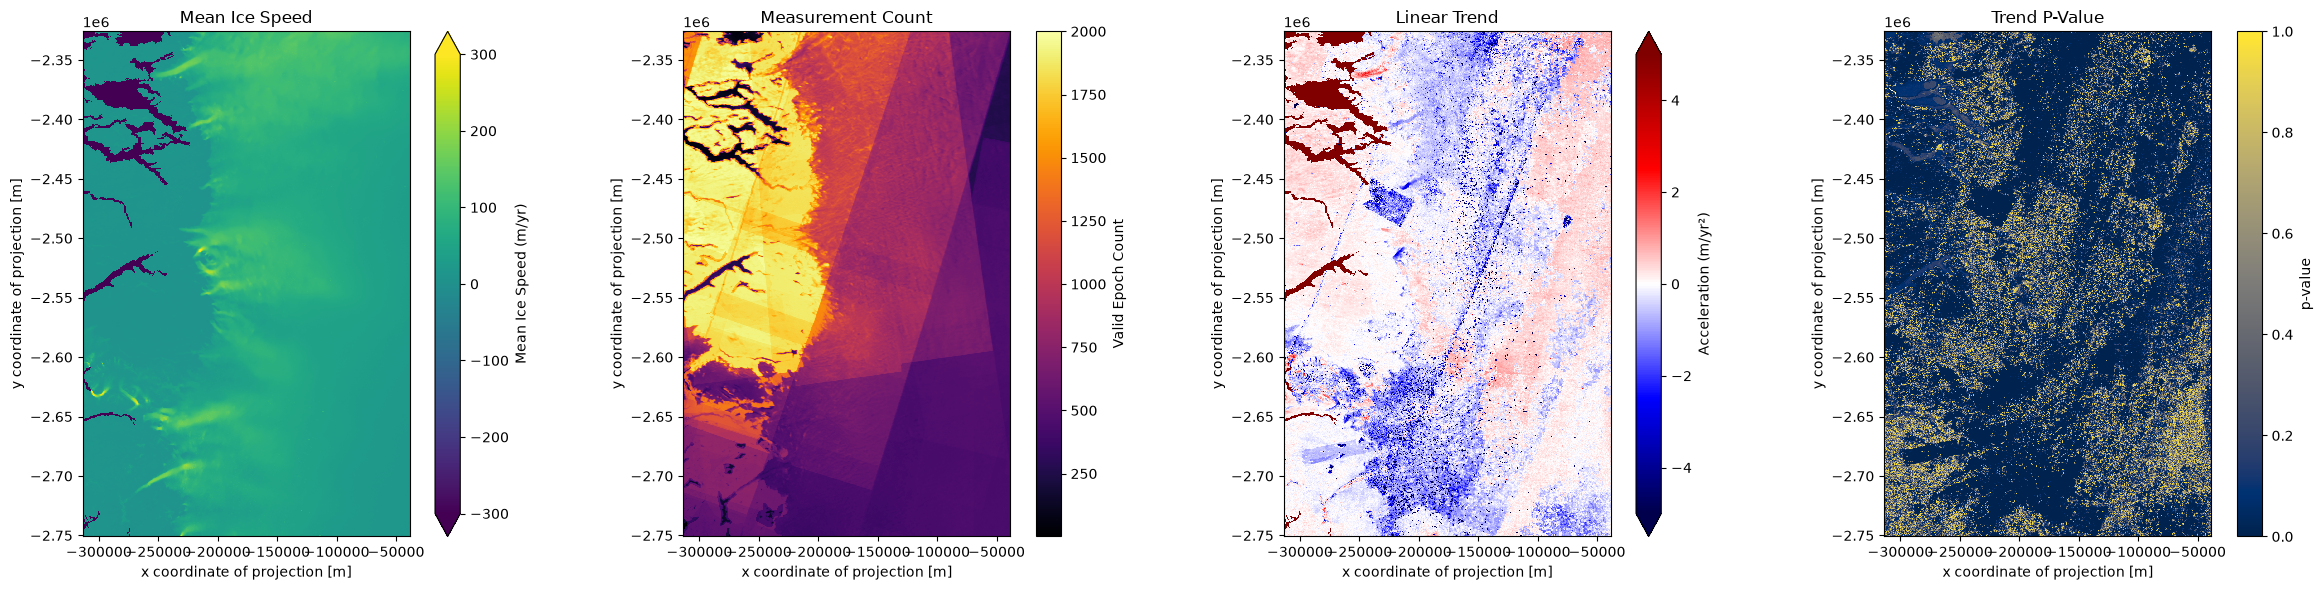

In [8]:
# Set up a plot with 4 subplots (1 row, 4 columns)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Plot 1: Mean Speed
mean_c.plot(ax=axes[0], cmap='viridis', vmax=300, 
            cbar_kwargs={'label': 'Mean Ice Speed (m/yr)'})
axes[0].set_title("Mean Ice Speed")
axes[0].set_aspect('equal')

# Plot 2: Measurement Count
count_c.plot(ax=axes[1], cmap='inferno', 
             cbar_kwargs={'label': 'Valid Epoch Count'})
axes[1].set_title("Measurement Count")
axes[1].set_aspect('equal')

# Plot 3: Linear Trend
# Centered colormap to easily differentiate acceleration (red) vs deceleration (blue)
slope_c.plot(ax=axes[2], cmap='seismic', vmin=-5, vmax=5, 
             cbar_kwargs={'label': 'Acceleration (m/yr²)'})
axes[2].set_title("Linear Trend")
axes[2].set_aspect('equal')

# Plot 4: P-value
# Scaled from 0 to 1 as standard for p-values
p_val_c.plot(ax=axes[3], cmap='cividis', vmin=0, vmax=1,
             cbar_kwargs={'label': 'p-value'})
axes[3].set_title("Trend P-Value")
axes[3].set_aspect('equal')

plt.tight_layout()
plt.show()

Which is neat because it broadly agrees with the results of Tedstone et al. (2015) and Williams et al (2020), showing a long-term deceleration of ice in the ablation zome of this land-terminating sector of west Greenland. Albeit the plots here are somewhat messier than theirs. In the next example, we'll have a go at reproducing those trends more robustly.